# Sugar Quality Inspection - Model Comparison and Analysis

This analysis includes:

- Ranked Comparison Table
- Bar Chart Visualization
- Best Model Selection

based on Test Accuracy, Validation Accuracy, and Training Efficiency

### Modules

In [48]:
import os
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': 'Times New Roman'})
plt.rcParams.update({'font.size': 14})

### Load CSV

In [49]:
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
RESULTS_FILE = os.path.join(ROOT_DIR, "Results", "model_results_sugar.csv")
print("Results file path:", RESULTS_FILE)
if not os.path.exists(RESULTS_FILE):
    print(f"Error: The file {RESULTS_FILE} does not exist.")
else:    
    print(f"The file {RESULTS_FILE} exists. Proceeding to read the data.")

Results file path: e:\Studies\MIT\8\Project\Results\model_results_sugar.csv
The file e:\Studies\MIT\8\Project\Results\model_results_sugar.csv exists. Proceeding to read the data.


In [50]:
df = pd.read_csv(RESULTS_FILE)

print("Loaded Results:\n")
df

Loaded Results:



,model_name,best_val_accuracy,best_val_loss,test_accuracy,epochs_trained
0,vit_base_patch16_224,0.95000,0.15824,78.0,39
1,resnet50,0.97917,0.10370,83.0,27
2,efficientnet_b0,0.95833,0.38447,74.5,12
3,swin_tiny_patch4_window7_224,0.96667,0.13492,86.0,22
4,convnext_tiny,0.96667,0.12236,84.5,28
5,vit_small_patch16_224,0.96667,0.10703,84.0,18
6,densenet121,0.96250,0.10246,86.0,13
7,mobilenetv3_large_100,0.95833,0.19571,77.5,15


### Ranked Comparison Table

In [51]:
df_sorted = df.sort_values(by="test_accuracy", ascending=False).reset_index(drop=True)

df_sorted.insert(0, "Rank", df_sorted.index + 1)

print("Ranked Model Comparison:\n")
df_sorted

Ranked Model Comparison:



,Rank,model_name,best_val_accuracy,best_val_loss,test_accuracy,epochs_trained
0,1,swin_tiny_patch4_window7_224,0.96667,0.13492,86.0,22
1,2,densenet121,0.96250,0.10246,86.0,13
2,3,convnext_tiny,0.96667,0.12236,84.5,28
3,4,vit_small_patch16_224,0.96667,0.10703,84.0,18
4,5,resnet50,0.97917,0.10370,83.0,27
5,6,vit_base_patch16_224,0.95000,0.15824,78.0,39
6,7,mobilenetv3_large_100,0.95833,0.19571,77.5,15
7,8,efficientnet_b0,0.95833,0.38447,74.5,12


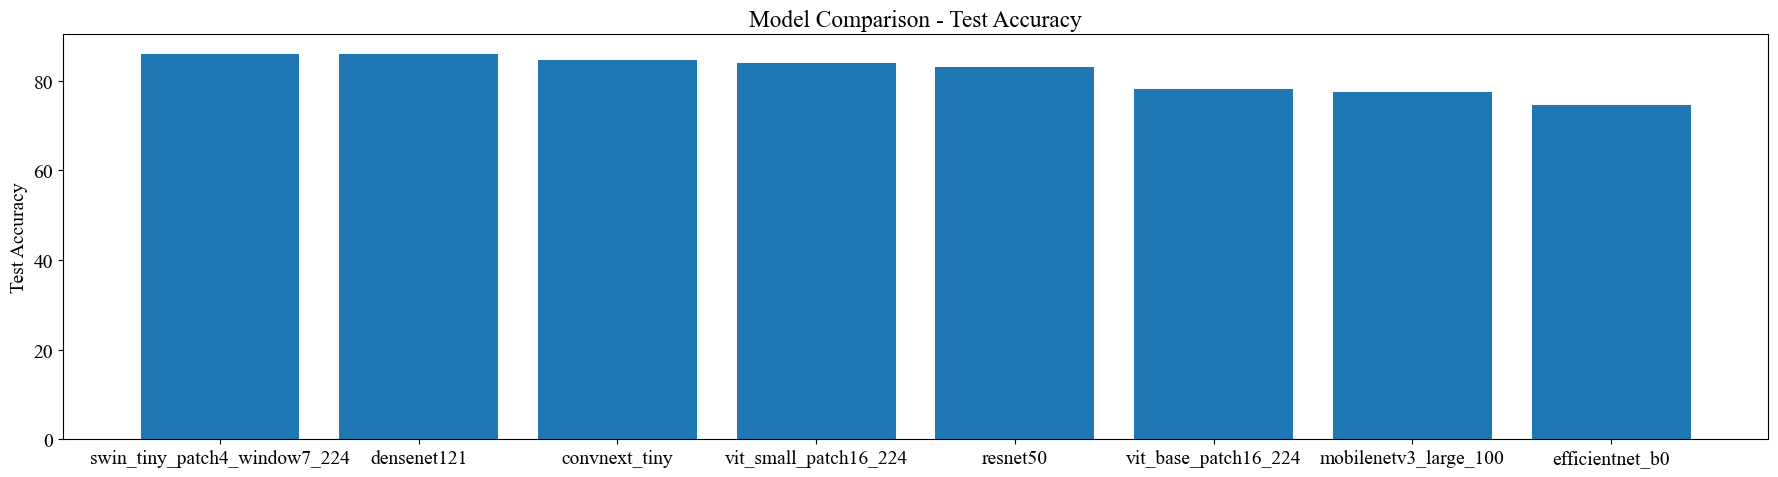

In [52]:
plt.figure(figsize=(18, 5))

plt.bar(df_sorted["model_name"], df_sorted["test_accuracy"])

# plt.xticks(rotation=30, ha="right")
plt.ylabel("Test Accuracy")
plt.title("Model Comparison - Test Accuracy")

plt.tight_layout()
plt.show()

### Training Efficiency Analysis

Training efficiency is evaluated using the number of epochs required before early stopping.

- Fewer epochs → faster convergence
- More epochs → slower convergence or harder optimization

This helps assess the trade-off between:
- performance
- computational cost

In [53]:
efficiency_df = df_sorted[["model_name", "test_accuracy", "epochs_trained"]]

print("Training Efficiency Comparison:\n")
efficiency_df

Training Efficiency Comparison:



,model_name,test_accuracy,epochs_trained
0,swin_tiny_patch4_window7_224,86.0,22
1,densenet121,86.0,13
2,convnext_tiny,84.5,28
3,vit_small_patch16_224,84.0,18
4,resnet50,83.0,27
5,vit_base_patch16_224,78.0,39
6,mobilenetv3_large_100,77.5,15
7,efficientnet_b0,74.5,12


### Best Model Selection

In [54]:
best_model_row = df_sorted.iloc[0]

best_model_name = best_model_row["model_name"]
best_test_acc = best_model_row["test_accuracy"]

print("Best Model Selected:")
print(f"Model: {best_model_name}")
print(f"Test Accuracy: {best_test_acc}")

Best Model Selected:
Model: swin_tiny_patch4_window7_224
Test Accuracy: 86.0


## Final Model Selection

The best-performing model is **swin_tiny_patch4_window7_224**, and it has been selected based on test accuracy.

This model demonstrates:

- Strong generalization on unseen data
- Stable validation performance
- Suitable characteristics for deployment